In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
torch.manual_seed(42)

# Check for GPU, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# 1. Load MNIST Data (Train and Test)
# We use 'None' as transform initially because we want to manipulate raw tensors first
# If you want look up transforms and it will show you how to do normalization etc here
train_data_raw = datasets.MNIST(root='../data', train=True, download=True, transform=None)
test_data_raw = datasets.MNIST(root='../data', train=False, download=True, transform=None)

def filter_and_prepare(dataset):
    # Access the data (N, 28, 28) and targets (N)
    x = dataset.data.float() / 255.0  # Normalize to image_index-1
    y = dataset.targets
    
    
    # 3. Relabel: '0','2' -> 0 (Class 0) and '1' -> 1 (Class 1)
    # We use a trick: (label == 1) returns True/False, convert to float
    # 3. Relabel
    y_labels = torch.tensor([     [1.,0,0,0,0,0,0,0,0,0] if y0 == 0 
                             else [0,1.,0,0,0,0,0,0,0,0] if y0 == 1 
                             else [0,0,1.,0,0,0,0,0,0,0] if y0 == 2
                             else [0,0,0,1.,0,0,0,0,0,0] if y0 == 3
                             else [0,0,0,0,1.,0,0,0,0,0] if y0 == 4
                             else [0,0,0,0,0,1.,0,0,0,0] if y0 == 5
                             else [0,0,0,0,0,0,1.,0,0,0] if y0 == 6
                             else [0,0,0,0,0,0,0,1.,0,0] if y0 == 7
                             else [0,0,0,0,0,0,0,0,1.,0] if y0 == 8
                             else [0,0,0,0,0,0,0,0,0,1.]
                             for y0 in y])#.unsqueeze(1)
    
    # Add Channel Dimension for CNN: (N, 28, 28) -> (N, 1, 28, 28)
    # PyTorch uses (Batch, Channel, Height, Width) unlike Keras' (B, H, W, C)
    x = x.unsqueeze(1)
    
    return x, y_labels

# Prepare Train and Test tensors
x_train, y_train = filter_and_prepare(train_data_raw)
x_test, y_test = filter_and_prepare(test_data_raw)

print(f"Filtered Train Shape: {x_train.shape}") # Should be (N, 1, 28, 28)
print(f"Filtered Test Shape: {x_test.shape}")
print(f"Label shape: {y_train.shape}, type: {type(y_train)}, label type {y_train.dtype}")


Filtered Train Shape: torch.Size([60000, 1, 28, 28])
Filtered Test Shape: torch.Size([10000, 1, 28, 28])
Label shape: torch.Size([60000, 10]), type: <class 'torch.Tensor'>, label type torch.float32


In [3]:
# Create DataLoaders (The iterator that feeds the model)
train_ds = TensorDataset(x_train, y_train)
test_ds = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

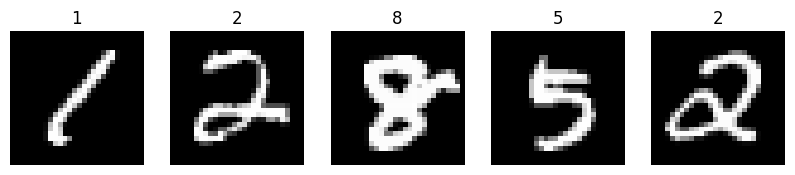

In [4]:
# Pull one batch to visualize
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    # PyTorch image is (1, 28, 28), we need to squeeze to (28, 28) for plotting
    plt.imshow(images[i].squeeze(), cmap='gray')
    label_name = labels[i].tolist().index(1)
    plt.title(f"{label_name}")
    plt.axis('off')
plt.show()

## Model 1 (my massive model)

In [5]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()

        # Activation, normalisation & dropout functions
        self.relu = nn.ReLU()
        self.bnorm32 = nn.BatchNorm2d(num_features=32)
        self.bnorm64 = nn.BatchNorm2d(num_features=64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop = nn.Dropout(p=0.4)

        # Layer 1: Conv (1 input channel -> 32 output channels)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same')
        
        # Layer 2: Conv (32 -> 32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3)

        # Layer 3: Conv (32 -> 32)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, padding='same')

        # Layer 4: Conv (32 -> 64)
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same')

        # Layer 5: Conv (64 -> 64)
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same')
        
        # Layer 6: Fully Connected
        self.fc1 = nn.Linear(2304, 64)
        self.out = nn.Linear(64, 10) # Output 10 values
        self.sigmoid = nn.Sigmoid() # Squash to 0-1
        
    def forward(self, x):
        # Layer 1
        x = self.relu(self.conv1(x))
        # Layer 2
        x = self.relu(self.conv2(x))
        # Layer 3
        x = self.pool(self.relu(self.conv3(x)))
        # Dropout
        x = self.drop(x)
        # Layer 4
        x = self.pool(self.relu(self.conv4(x)))
        # Layer 5
        x = self.relu(self.conv5(x))
        # Dropout
        x = self.drop(x)
        
        # Flatten: (Batch, 64, 1, 1) -> (Batch, 64)
        x = x.view(x.size(0), -1) 
        
        # Dense Layers
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.sigmoid(self.out(x))
        return x

model = BinaryCNN().to(device)

In [6]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 32, 26, 26]           9,248
              ReLU-4           [-1, 32, 26, 26]               0
            Conv2d-5           [-1, 32, 26, 26]          25,632
              ReLU-6           [-1, 32, 26, 26]               0
         MaxPool2d-7           [-1, 32, 13, 13]               0
           Dropout-8           [-1, 32, 13, 13]               0
            Conv2d-9           [-1, 64, 13, 13]          18,496
             ReLU-10           [-1, 64, 13, 13]               0
        MaxPool2d-11             [-1, 64, 6, 6]               0
           Conv2d-12             [-1, 64, 6, 6]          36,928
             ReLU-13             [-1, 64, 6, 6]               0
          Dropout-14             [-1, 6

## Model 2 (nice model I found online)

In [10]:
# adapted from https://nextjournal.com/gkoehler/pytorch-mnist

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.4)
        self.sigmoid = nn.Sigmoid() # Squash to 0-1

    def forward(self, x):
        x = self.relu(self.pool(self.conv1(x)))
        x = self.relu(self.pool(self.conv2_drop(self.conv2(x))))
        x = x.view(-1, 320)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return self.sigmoid(x)

model = Net().to(device)

In [11]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 10, 24, 24]             260
         MaxPool2d-2           [-1, 10, 12, 12]               0
              ReLU-3           [-1, 10, 12, 12]               0
            Conv2d-4             [-1, 20, 8, 8]           5,020
         Dropout2d-5             [-1, 20, 8, 8]               0
         MaxPool2d-6             [-1, 20, 4, 4]               0
              ReLU-7             [-1, 20, 4, 4]               0
            Linear-8                   [-1, 50]          16,050
              ReLU-9                   [-1, 50]               0
          Dropout-10                   [-1, 50]               0
           Linear-11                   [-1, 10]             510
          Sigmoid-12                   [-1, 10]               0
Total params: 21,840
Trainable params: 21,840
Non-trainable params: 0
---------------------------------

## Model 3 - smaller model for cpu

In [7]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()

        # Activation, normalisation & dropout functions
        self.relu = nn.ReLU()
        self.bnorm32 = nn.BatchNorm2d(num_features=32)
        self.bnorm64 = nn.BatchNorm2d(num_features=64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop = nn.Dropout(p=0.4)

        # Layer 1: Conv (1 input channel -> 32 output channels)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same')

        # Layer 2: Conv (32 -> 64)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same')
        
        # Layer 3: Fully Connected
        self.fc1 = nn.Linear(12544, 64)

        # Layer 4: Fully Connected
        self.out = nn.Linear(64, 10) # Output 10 values
        self.sigmoid = nn.Sigmoid() # Squash to 0-1
        
    def forward(self, x):
        # Layer 1
        x = self.relu(self.conv1(x))
        # Layer 2
        x = self.pool(self.relu(self.conv2(x)))
        # Dropout
        x = self.drop(x)
        
        # Flatten: (Batch, 64, 1, 1) -> (Batch, 64)
        x = x.view(x.size(0), -1) 
        
        # Dense Layers
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.sigmoid(self.out(x))
        return x

model = BinaryCNN().to(device)

In [8]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 64, 28, 28]          18,496
              ReLU-4           [-1, 64, 28, 28]               0
         MaxPool2d-5           [-1, 64, 14, 14]               0
           Dropout-6           [-1, 64, 14, 14]               0
            Linear-7                   [-1, 64]         802,880
              ReLU-8                   [-1, 64]               0
           Dropout-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
          Sigmoid-11                   [-1, 10]               0
Total params: 822,346
Trainable params: 822,346
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/

## Train model

In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss() # Mean absolute error
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []

print("Starting Training...")

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in train_loader:
        # Move data to GPU/MPS if available
        images, labels = images.to(device), labels.to(device)
        
        # 1. Zero Gradients (Clear previous step's history)
        optimizer.zero_grad()
        
        # 2. Forward Pass (Make prediction)
        outputs = model(images)
        
        # 3. Calculate Loss (Compare prediction to ground truth)
        loss = criterion(outputs, labels)
        
        # 4. Backward Pass (Calculate gradients via Backprop)
        loss.backward()
        
        # 5. Optimizer Step (Update weights)
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print("Training Complete!")

Starting Training...


Final Test Accuracy: 99.47%


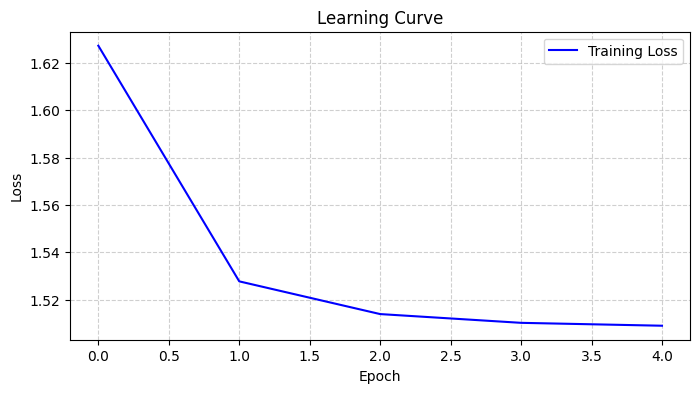

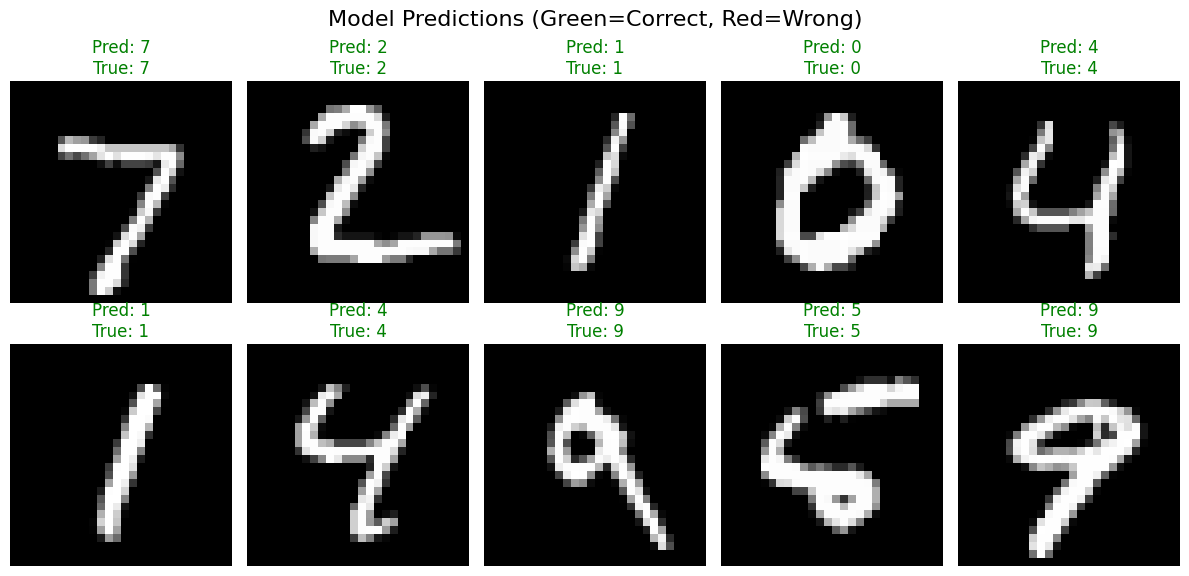

In [65]:
# 1. Switch to Evaluation Mode
model.eval()

correct = 0
total = 0

# 2. Turn off Gradient Tracking
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 10 #* 100
print(f"Final Test Accuracy: {accuracy:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Get one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make predictions
images_device = images.to(device)
outputs = model(images_device)
preds = (outputs > 0.5).float()

# Plot a 2x5 Grid
plt.figure(figsize=(12, 6))
plt.suptitle("Model Predictions (Green=Correct, Red=Wrong)", fontsize=16)

for idx in range(10):
    ax = plt.subplot(2, 5, idx + 1) # Simple 1-10 index
    
    # Process image (remove channel dim, convert to numpy)
    img_np = images[idx].squeeze().numpy()
    ax.imshow(img_np, cmap='gray')
    ax.axis('off')
    
    # Determine labels
    pred_val = preds[idx].tolist().index(1)
    true_val = labels[idx].tolist().index(1)
    
    ax.set_title(f"Pred: {pred_val}\nTrue: {true_val}", fontsize=12, color="green" if pred_val == true_val else "red")

plt.tight_layout()
plt.show()

In [ ]:
image_index = 4

image = x_test[image_index].unsqueeze(1)
model.eval()
output = model(image)

print(f"Input shape: {image.shape}, Output Shape: {output.shape}")
print(f"True value: {y_test[image_index].tolist().index(1)}, Predicted value: {output.tolist()[0].index(1)}")

Input shape: torch.Size([1, 1, 28, 28]), Output Shape: torch.Size([1, 10])
True value: 4, Predicted value: 4


In [ ]:
torch.save(model.state_dict(), '../models')